# Motor current and vibration dataset for various faults in an E-motor-driven centrifugal pump #
Welcome to this notebook. In this notebook a difficult problem is presented. Could you predict the failure mode of a motor with it's electrical and vibration data?<br>
Some help is given at the begin. ***At the end some assignments are given!***


For a description of the original data see: https://www.sciencedirect.com/science/article/pii/S235234092301017X?via%3Dihub

To download an excel with a more detailed overview of the data: https://github.com/bbozon/DataScience/blob/main/measurement%20overview.xlsx <br>
(click the download button at the right )

I've added a fourier transform of the original data (the data is translated to the frequency domain).
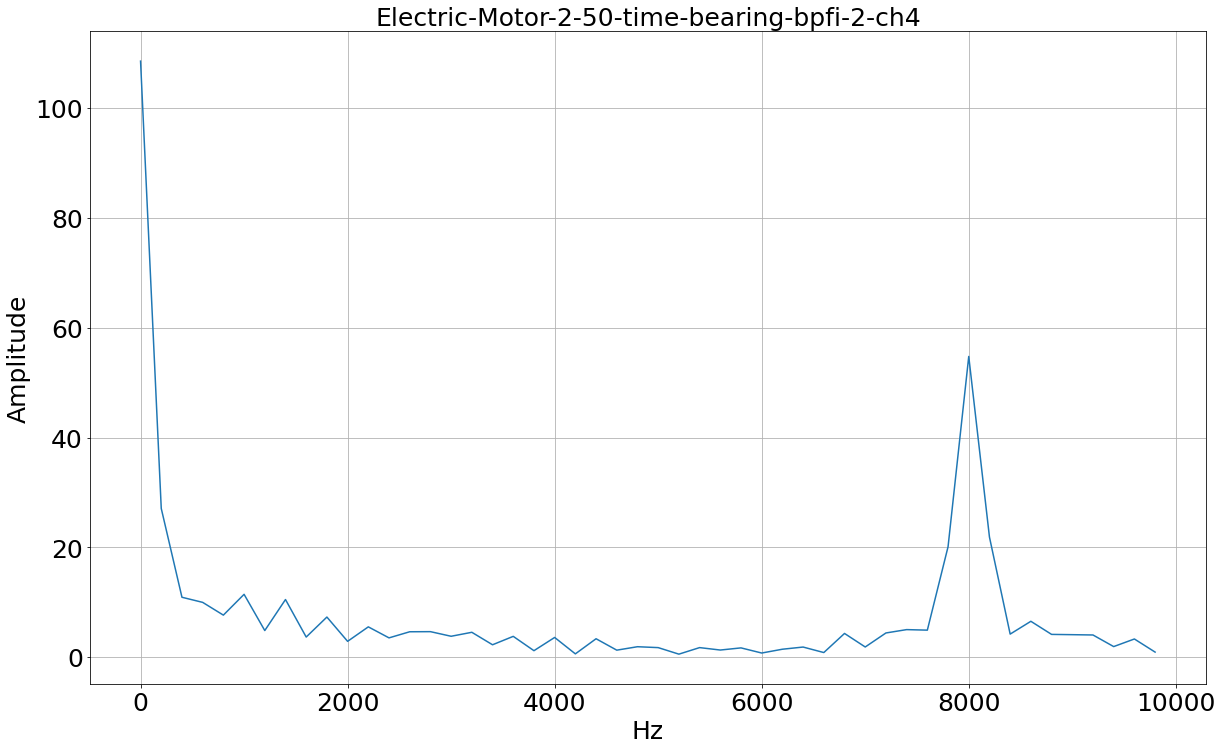

In the example below the frequency data is added as extra columns.

Written by Bart Bozon, please copy & use as you would like.

In [10]:
import pandas as pd
url = 'https://raw.githubusercontent.com/bbozon/DataScience/refs/heads/main/motor_data_electrical_and_vibration_time_and_frequency.csv'
df = pd.read_csv(url)
# df.head(20)
df

,num,file_name,motor_type,measurement_type,percentage_rated_speed,failure_mode,channels,0.0 [s],5e-05 [s],0.0001 [s],...,8000.0 [Hz],8200.0 [Hz],8400.0 [Hz],8600.0 [Hz],8800.0 [Hz],9000.0 [Hz],9200.0 [Hz],9400.0 [Hz],9600.0 [Hz],9800.0 [Hz]
0,0,Electric-Motor-2-100-time-bearing-bpfi-1-ch1,2,Electric,100,bearing-bpfi-1,ch1,12.538880,11.504028,11.892352,...,0.460920,0.505890,0.491107,0.478344,0.464159,0.460195,0.455085,0.445983,0.442841,0.444571
1,1,Electric-Motor-2-100-time-bearing-bpfi-1-ch2,2,Electric,100,bearing-bpfi-1,ch2,13.997547,14.728688,14.463031,...,0.281560,0.178401,0.175755,0.158460,0.148352,0.140856,0.131986,0.131468,0.136013,0.136019
2,2,Electric-Motor-2-100-time-bearing-bpfi-1-ch3,2,Electric,100,bearing-bpfi-1,ch3,-25.848821,-25.387859,-25.563526,...,0.486832,0.399209,0.327249,0.328707,0.322791,0.323270,0.323412,0.317095,0.311970,0.311122
3,3,Electric-Motor-2-100-time-bearing-bpfi-1-ch4,2,Electric,100,bearing-bpfi-1,ch4,-126.612758,-54.756134,-44.005587,...,8.222805,12.140835,7.765923,5.993686,4.849380,5.181368,5.188414,4.162534,3.393596,3.880727
4,4,Electric-Motor-2-100-time-bearing-bpfi-1-ch5,2,Electric,100,bearing-bpfi-1,ch5,280.423727,297.966561,280.213054,...,7.933788,2.230050,3.447050,2.596825,2.126454,1.815192,1.717921,1.534892,1.157102,0.935014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7657,7657,Vibration-Motor-4-70-time-unbalance-pump-3-ch1,4,Vibration,70,unbalance-pump-3,ch1,0.431913,0.030839,0.331461,...,0.097905,0.086127,0.037719,0.082455,0.158598,0.113416,0.132084,0.233835,0.108244,0.111489
7658,7658,Vibration-Motor-4-70-time-unbalance-pump-3-ch2,4,Vibration,70,unbalance-pump-3,ch2,0.121140,-0.163805,-0.110310,...,0.033157,0.028357,0.039017,0.006492,0.041775,0.060323,0.103699,0.192294,0.322833,0.419497
7659,7659,Vibration-Motor-4-70-time-unbalance-pump-3-ch3,4,Vibration,70,unbalance-pump-3,ch3,0.379044,-0.513494,0.479150,...,0.015550,0.018630,0.070879,0.121620,0.029988,0.030370,0.065686,0.152170,0.254682,0.550237
7660,7660,Vibration-Motor-4-70-time-unbalance-pump-3-ch4,4,Vibration,70,unbalance-pump-3,ch4,-0.211090,-0.318730,-0.272679,...,0.048559,0.015695,0.018430,0.011283,0.008598,0.009770,0.021162,0.016608,0.015716,0.030339


In [11]:
df.columns

Index(['num', 'file_name', 'motor_type', 'measurement_type',
       'percentage_rated_speed', 'failure_mode', 'channels', '0.0 [s]',
       '5e-05 [s]', '0.0001 [s]',
       ...
       '8000.0 [Hz]', '8200.0 [Hz]', '8400.0 [Hz]', '8600.0 [Hz]',
       '8800.0 [Hz]', '9000.0 [Hz]', '9200.0 [Hz]', '9400.0 [Hz]',
       '9600.0 [Hz]', '9800.0 [Hz]'],
      dtype='object', length=157)

We'll try a simple model on a subset of the problem, we will look at motor 2 at 50% rated speed. We will use the vibration data of channel 3 as feature set.

This is just an attempt. I bet YOU can do better...

1) Investigate the data in more detail. <br>
2) Can you get better results with a different selection of your input? E.g. different motor, different type of data (vibration/electrical), different measurement point (ch1-ch2-ch3-...)?<br>
3a) Read: https://medium.com/analytics-vidhya/categorical-encoding-with-pandas-get-dummies-d6f1ae6a3e06 <br>
3b) Can you get better results with "get_dummies"? So combining more data?<br>
4) Can you get better results with the time data set? <br>
4) Can you get better results with other models?<br>

You do not have to do the items sequentially, better yet, you can combine them. Do keep note of all your different results! It'easy to loose track...  


Step 1: analyzing the data

The frist theng i noticed was the dataset is realy small and comes from dirfferent fyles. eatch motor has 6 current chanels and 6 vibration channels. all this data belongs to one motor at the same time so this data all needs to be in the same row

In [12]:
import pandas as pd
import re

def process_and_clean_motor_data(df):
    print(f"📥 Originele grootte: {df.shape}")

    # --- STAP 1: Logische kolomnamen maken (Prefixes) ---
    def get_col_prefix(row):
        m_type = str(row['measurement_type'])
        
        # --- DE FIX: 'ch' strippen ---
        # Haal de waarde op (bijv. 'ch3' of 3)
        raw_ch = str(row['channels']) # Let op: check of je kolom 'channels' of 'channel' heet
        
        # Gebruik regex om alleen de cijfers te vinden
        # Dit werkt voor 'ch3', 'channel-3', '3', etc.
        match = re.search(r'(\d+)', raw_ch)
        if match:
            ch = int(match.group(1))
        else:
            return f"Unknown_Ch_{raw_ch}" # Fallback als er geen getal is

        # De logica voor de namen
        if 'Electric' in m_type:
            if 1 <= ch <= 3: return f"Current_Ph{ch}"
            if 4 <= ch <= 6: return f"Voltage_Ph{ch-3}"
        elif 'Vibration' in m_type:
            return f"Vib_Sens{ch}"
        return f"Unknown_Ch{ch}"

    # Pas toe op elke rij
    # Zorg dat axis=1 staat zodat hij per rij werkt
    df['col_prefix'] = df.apply(get_col_prefix, axis=1)

    # --- STAP 2: Data Pivoten ---
    # Unieke sleutel per experiment: Motor + Snelheid + Fout
    group_cols = ['motor_type', 'percentage_rated_speed', 'failure_mode']
    
    freq_cols = [c for c in df.columns if '[Hz]' in c]
    
    print(f"🔄 Samenvoegen van rijen naar 1 rij o.b.v. {group_cols}...")
    
    df_pivot = df.pivot_table(
        index=group_cols,       
        columns='col_prefix',   
        values=freq_cols,       
        aggfunc='first'
    )

    # Kolommen platslaan
    df_pivot.columns = [f"{col[1]}_{col[0]}" for col in df_pivot.columns]
    
    df_final = df_pivot.reset_index()

    # --- STAP 3: Failure Mode Opschonen ---
    # "bearing-bpfi-1" -> "bearing-bpfi"
    def clean_failure_label(val):
        return re.sub(r'-\d+$', '', str(val))

    df_final['failure_mode_cleaned'] = df_final['failure_mode'].apply(clean_failure_label)

    print(f"✅ Klaar! Nieuwe grootte: {df_final.shape}")
    return df_final

# --- GEBRUIK ---
df_wide = process_and_clean_motor_data(df.copy())
df_wide.head(50)

📥 Originele grootte: (7662, 157)
🔄 Samenvoegen van rijen naar 1 rij o.b.v. ['motor_type', 'percentage_rated_speed', 'failure_mode']...
✅ Klaar! Nieuwe grootte: (118, 554)


,motor_type,percentage_rated_speed,failure_mode,Current_Ph1_0.0 [Hz],Current_Ph2_0.0 [Hz],Current_Ph3_0.0 [Hz],Vib_Sens1_0.0 [Hz],Vib_Sens2_0.0 [Hz],Vib_Sens3_0.0 [Hz],Vib_Sens4_0.0 [Hz],...,Current_Ph3_9800.0 [Hz],Vib_Sens1_9800.0 [Hz],Vib_Sens2_9800.0 [Hz],Vib_Sens3_9800.0 [Hz],Vib_Sens4_9800.0 [Hz],Vib_Sens5_9800.0 [Hz],Voltage_Ph1_9800.0 [Hz],Voltage_Ph2_9800.0 [Hz],Voltage_Ph3_9800.0 [Hz],failure_mode_cleaned
0,2,50,bearing-bpfi-1,10.770253,12.509463,23.280789,0.041058,0.018262,0.004547,0.012667,...,0.023437,0.030906,0.029306,0.000425,0.003822,0.011182,1.341122,1.898672,0.162844,bearing-bpfi
1,2,50,bearing-bpfi-2,4.502600,18.699810,21.785153,0.001730,0.002416,0.005624,0.001287,...,0.018900,0.040022,0.018551,0.000765,0.008571,0.004136,0.934688,1.958151,2.061394,bearing-bpfi
2,2,50,bearing-bpfi-3,22.693504,15.470816,8.478259,NaN,NaN,NaN,NaN,...,0.091113,NaN,NaN,NaN,NaN,NaN,0.327269,2.639039,0.416005,bearing-bpfi
3,2,50,bearing-bpfo-1,19.382642,21.509869,0.581089,0.001320,0.010221,0.003306,0.002559,...,0.090858,0.019681,0.003297,0.000614,0.008209,0.009943,3.598286,0.685198,2.781163,bearing-bpfo
4,2,50,bearing-bpfo-2,22.866790,4.058911,18.294994,0.019472,0.007485,0.002025,0.016527,...,0.015580,0.022969,0.012961,0.000341,0.002442,0.006595,2.590624,0.429982,3.927980,bearing-bpfo
5,2,50,bearing-bpfo-3,19.065174,3.160004,21.411064,0.008269,0.009528,0.000499,0.002808,...,0.016914,0.009639,0.029749,0.000454,0.006100,0.004399,0.477473,2.459171,1.663991,bearing-bpfo
6,2,50,bearing-bsf,7.474028,16.434507,22.537934,0.006858,0.019305,0.003913,0.009080,...,0.024519,0.019236,0.076941,0.001373,0.006831,0.004454,1.922390,2.227355,1.760098,bearing-bsf
7,2,50,bearing-contaminated,9.031575,14.307437,23.305383,0.002493,0.010620,0.002357,0.008214,...,0.006744,0.015785,0.016587,0.001141,0.006351,0.008313,0.167871,0.623278,2.202970,bearing-contaminated
8,2,50,bearing-pump-1,12.811555,11.600963,23.213894,0.004002,0.001986,0.004273,0.022264,...,0.021475,0.027008,0.029609,0.003108,0.009650,0.035365,2.968256,4.224489,4.213499,bearing-pump
9,2,50,bearing-pump-2,23.722884,15.763910,8.101140,0.015865,0.010058,0.005773,0.027204,...,0.080363,0.012239,0.014584,0.002186,0.019066,0.028441,0.725097,0.432743,0.329339,bearing-pump


In [13]:
import pandas as pd
import re

def custom_motor_data_merger(df):
    print(f"📥 Original dataset size: {df.shape}")

    # --- STEP 1: PREPARATION (Cleaning Group Columns) ---
    # Ensure that data types match so '100' (string) and 100 (int) are treated as the same group.
    df['percentage_rated_speed'] = pd.to_numeric(df['percentage_rated_speed'], errors='coerce').fillna(0).astype(int)
    df['motor_type'] = df['motor_type'].astype(str).str.strip()
    df['failure_mode'] = df['failure_mode'].astype(str).str.strip()

    # --- STEP 2: CREATE LOGICAL COLUMN PREFIXES ---
    # This defines the new column names (e.g., Current_Ph1, Vib_Sens1) based on channel info.
    def get_col_prefix(row):
        m_type = str(row['measurement_type'])
        
        # Robustly extract channel number from string (e.g., 'ch1' -> 1)
        raw_ch = str(row['channels'])
        match = re.search(r'(\d+)', raw_ch)
        ch = int(match.group(1)) if match else 0
        
        if 'Electric' in m_type:
            if 1 <= ch <= 3: return f"Current_Ph{ch}"
            if 4 <= ch <= 6: return f"Voltage_Ph{ch-3}"
        elif 'Vibration' in m_type:
            return f"Vib_Sens{ch}"
        return f"Unknown_Ch_{ch}"

    df['col_prefix'] = df.apply(get_col_prefix, axis=1)

    # --- STEP 3: CUSTOM MERGE FUNCTION (The Logic You Requested) ---
    
    # Define the columns that identify a unique experiment
    group_cols = ['motor_type', 'percentage_rated_speed', 'failure_mode']
    
    # Identify the frequency columns (data to keep)
    freq_cols = [c for c in df.columns if '[Hz]' in c]
    
    print(f"\n🔄 Starting custom merge process...")
    print(f"   Grouping by: {group_cols}")

    # List to store the successfully merged rows
    merged_rows = []
    
    # Iterate through each unique group (equivalent to "finding all rows with same data")
    # grouped is an iterator of (key, dataframe_slice)
    grouped = df.groupby(group_cols)
    
    params_processed = 0
    errors_log = []

    for group_keys, group_df in grouped:
        params_processed += 1
        
        # CHECK: Does this group have exactly 11 measurements?
        # (6 Electrical + 5 Vibration)
        if len(group_df) != 11:
            # Log the error and SKIP this group
            error_msg = f"❌ Mismatch found! Group {group_keys} has {len(group_df)} rows (expected 11). Skipping..."
            print(error_msg)
            errors_log.append(error_msg)
            continue 
        
        # If we are here, we have exactly 11 rows. Let's merge them.
        
        # 1. Create the base dictionary with the group info (Motor, Speed, Failure)
        # group_keys is a tuple: (motor_type, speed, failure_mode)
        new_row = {
            'motor_type': group_keys[0],
            'percentage_rated_speed': group_keys[1],
            'failure_mode': group_keys[2]
        }
        
        # 2. Flatten the data
        # For each row in this group (which represents 1 sensor), grab the Hz data
        for _, row in group_df.iterrows():
            prefix = row['col_prefix'] # e.g., "Current_Ph1"
            
            # Add all frequency columns to the new_row with the prefix
            for freq_col in freq_cols:
                new_col_name = f"{prefix}_{freq_col}"
                new_row[new_col_name] = row[freq_col]
        
        # 3. Add the complete merged row to our list
        merged_rows.append(new_row)

    # --- STEP 4: CREATE FINAL DATAFRAME ---
    df_final = pd.DataFrame(merged_rows)

    # --- STEP 5: CLEAN FAILURE LABEL (Post-Merge) ---
    # Remove the trailing number (e.g., "bearing-bpfi-1" -> "bearing-bpfi")
    if not df_final.empty:
        df_final['failure_mode_cleaned'] = df_final['failure_mode'].apply(lambda x: re.sub(r'-\d+$', '', str(x)))

    print(f"\n✅ Process Completed.")
    print(f"   - Groups processed: {params_processed}")
    print(f"   - Valid experiments (11 rows): {len(df_final)}")
    print(f"   - Incomplete experiments dropped: {len(errors_log)}")
    
    if len(errors_log) > 0:
        print("\n⚠️ Summary of dropped data:")
        for log in errors_log[:5]: # Print first 5 errors
            print(f"   {log}")
        if len(errors_log) > 5:
            print(f"   ... and {len(errors_log) - 5} more.")

    return df_final

# --- USAGE ---
df_wide = custom_motor_data_merger(df.copy())
df_wide.head()

📥 Original dataset size: (7662, 157)

🔄 Starting custom merge process...
   Grouping by: ['motor_type', 'percentage_rated_speed', 'failure_mode']
❌ Mismatch found! Group ('2', np.int64(50), 'bearing-bpfi-1') has 66 rows (expected 11). Skipping...
❌ Mismatch found! Group ('2', np.int64(50), 'bearing-bpfi-2') has 66 rows (expected 11). Skipping...
❌ Mismatch found! Group ('2', np.int64(50), 'bearing-bpfi-3') has 36 rows (expected 11). Skipping...
❌ Mismatch found! Group ('2', np.int64(50), 'bearing-bpfo-1') has 66 rows (expected 11). Skipping...
❌ Mismatch found! Group ('2', np.int64(50), 'bearing-bpfo-2') has 66 rows (expected 11). Skipping...
❌ Mismatch found! Group ('2', np.int64(50), 'bearing-bpfo-3') has 66 rows (expected 11). Skipping...
❌ Mismatch found! Group ('2', np.int64(50), 'bearing-bsf') has 66 rows (expected 11). Skipping...
❌ Mismatch found! Group ('2', np.int64(50), 'bearing-contaminated') has 66 rows (expected 11). Skipping...
❌ Mismatch found! Group ('2', np.int64(50),

""


This is not working, i got 6 times as mutch data. and malualy it looks like the data repeeds 6 times based on file names



In [14]:
import pandas as pd
import numpy as np

# 1. Instellingen
chunk_size = 1277
import pandas as pd
import numpy as np

# Aanname: df is al geladen
# df = pd.read_csv(...)

# 1. Instellingen
chunk_size = 1277
n_chunks = 6
total_rows = len(df)

print(f"Totaal aantal rijen: {total_rows}")

if total_rows != chunk_size * n_chunks:
    print(f"⚠️ Let op: De datasetlengte ({total_rows}) is niet precies {chunk_size} * {n_chunks}.")
else:
    print(f"✅ De dataset is precies {n_chunks} keer {chunk_size} lang.")

    # 2. Opsplitsen (En 'num' verwijderen indien aanwezig)
    # We checken eerst of 'num' bestaat om errors te voorkomen
    cols_to_drop = ["num"] if "num" in df.columns else []
    
    chunks = [
        df.drop(cols_to_drop, axis=1)
          .iloc[i*chunk_size : (i+1)*chunk_size]
          .reset_index(drop=True) 
        for i in range(n_chunks)
    ]

    # 3. Vergelijken met het eerste blok (Chunk 0)
    print("\n--- Vergelijking met het eerste blok (Chunk 0) ---")
    all_identical = True
    
    for i in range(1, n_chunks):
        is_equal = chunks[0].equals(chunks[i])
        if is_equal:
            print(f"Chunk {i}: EXACT KOPIE van Chunk 0")
        else:
            all_identical = False
            print(f"Chunk {i}: Verschilt van Chunk 0")
            
            # 4. Waar zitten de verschillen?
            # LET OP DE WIJZIGING HIERONDER:
            # We loopen over chunks[0].columns, NIET over df.columns
            # Anders crasht hij op de weggelaten 'num' kolom.
            
            diff_cols = []
            for col in chunks[0].columns:
                # We vullen NaN met een placeholder om fouten te voorkomen bij vergelijken
                c1 = chunks[0][col].fillna('NAN')
                c2 = chunks[i][col].fillna('NAN')
                
                if not (c1 == c2).all():
                    diff_cols.append(col)
            
            print(f"   -> Verschillende kolommen: {diff_cols[:5]} {'...' if len(diff_cols)>5 else ''}")
            
            # Check specifiek de bestandsnaam of kanaal als die nog bestaat
            if 'file_name' in chunks[0].columns:
                print(f"   -> Voorbeeld file_name Chunk 0: {chunks[0]['file_name'].iloc[0]}")
                print(f"   -> Voorbeeld file_name Chunk {i}: {chunks[i]['file_name'].iloc[0]}")

    if all_identical:
        print("\nCONCLUSIE: Je dataset bestaat uit 6 identieke kopieën (Duplicaten!).")
    else:
        print("\nCONCLUSIE: De blokken zijn NIET identiek. Waarschijnlijk zijn het de 6 verschillende kanalen (Sensors) achter elkaar geplakt.")

Totaal aantal rijen: 7662
✅ De dataset is precies 6 keer 1277 lang.

--- Vergelijking met het eerste blok (Chunk 0) ---
Chunk 1: Verschilt van Chunk 0
   -> Verschillende kolommen: ['0.0 [s]', '5e-05 [s]', '0.0001 [s]', '0.00015 [s]', '0.0002 [s]'] ...
   -> Voorbeeld file_name Chunk 0: Electric-Motor-2-100-time-bearing-bpfi-1-ch1
   -> Voorbeeld file_name Chunk 1: Electric-Motor-2-100-time-bearing-bpfi-1-ch1
Chunk 2: Verschilt van Chunk 0
   -> Verschillende kolommen: ['0.0 [s]', '5e-05 [s]', '0.0001 [s]', '0.00015 [s]', '0.0002 [s]'] ...
   -> Voorbeeld file_name Chunk 0: Electric-Motor-2-100-time-bearing-bpfi-1-ch1
   -> Voorbeeld file_name Chunk 2: Electric-Motor-2-100-time-bearing-bpfi-1-ch1
Chunk 3: Verschilt van Chunk 0
   -> Verschillende kolommen: ['0.0 [s]', '5e-05 [s]', '0.0001 [s]', '0.00015 [s]', '0.0002 [s]'] ...
   -> Voorbeeld file_name Chunk 0: Electric-Motor-2-100-time-bearing-bpfi-1-ch1
   -> Voorbeeld file_name Chunk 3: Electric-Motor-2-100-time-bearing-bpfi-1-ch1
C

The data was not saved in astructured way. There are 6 times the same datafile but the data is not structured. after reading the documentatnion the vibrations and the electrical measurements aren't made at the same time. this meens that is isn't reccomended to combine the data. making the measurements at the same time woul be smart.

This means the best approatch is to make 2 different types of datasetes 1 for vibrations and one for electrical. This data should't be in the same data set as the are compleaty different types of inputs. this means atleast 2 different models need to be made. one for vibration and one for electrical. All the cnallens need to be combinend becouse more realaided data could worck bettern


In [15]:
import pandas as pd
import numpy as np
import re

def reshape_sensor_data_by_channels(df_input, sensor_type_label, num_channels):
    """
    Splits a sensor dataframe into a fixed number of channels (chunks) 
    and merges them horizontally.
    
    Logic: chunk_size = total_rows / num_channels
    """
    total_rows = len(df_input)
    
    # 1. Calculate chunk size based on fixed number of channels
    if total_rows % num_channels != 0:
        print(f"⚠️ Warning: {sensor_type_label} total rows ({total_rows}) is not divisible by {num_channels} channels!")
        print("   - Data might be incomplete or contain extra rows.")
        return None
        
    chunk_size = total_rows // num_channels
    
    print(f"\n🔄 Processing {sensor_type_label}...")
    print(f"   - Total rows: {total_rows}")
    print(f"   - Number of Channels: {num_channels}")
    print(f"   - Calculated Chunk Size (rows per experiment): {chunk_size}")

    processed_chunks = []

    for i in range(num_channels):
        # Calculate start and end index for this channel
        start = i * chunk_size
        end = (i + 1) * chunk_size
        
        # Slice the chunk and reset index to allow horizontal stacking
        chunk = df_input.iloc[start:end].reset_index(drop=True)
        
        # --- Determine Channel Name ---
        # We assume the data is sorted by channel (e.g. first chunk is Ch1, second is Ch2)
        ch_num = i + 1
        
        # Define Prefix based on Sensor Type and Channel Number
        prefix = f"Unknown_{ch_num}"
        
        if sensor_type_label == 'Electric':
            if 1 <= ch_num <= 3: prefix = f"Current_Ph{ch_num}"
            elif 4 <= ch_num <= 6: prefix = f"Voltage_Ph{ch_num-3}"
        elif sensor_type_label == 'Vibration':
            prefix = f"Vib_Sens{ch_num}"
            
        # --- Rename Frequency Columns ---
        # Select frequency columns (containing '[Hz]')
        freq_cols = [c for c in chunk.columns if '[Hz]' in c]
        
        # Rename map: "8600 [Hz]" -> "Current_Ph1_8600 [Hz]"
        rename_map = {col: f"{prefix}_{col}" for col in freq_cols}
        chunk_renamed = chunk[freq_cols].rename(columns=rename_map)
        
        # --- Keep Metadata (Only for the first chunk) ---
        # We attach experiment metadata only once (to chunk 0)
        if i == 0:
            meta_cols = ['motor_type', 'percentage_rated_speed', 'failure_mode']
            existing_meta = [c for c in meta_cols if c in chunk.columns]
            chunk_renamed = pd.concat([chunk[existing_meta], chunk_renamed], axis=1)
        
        processed_chunks.append(chunk_renamed)

    # 2. Merge all chunks horizontally
    df_wide = pd.concat(processed_chunks, axis=1)
    
    # 3. Clean Failure Label
    if 'failure_mode' in df_wide.columns:
        df_wide['failure_mode_cleaned'] = df_wide['failure_mode'].apply(lambda x: re.sub(r'-\d+$', '', str(x)))

    print(f"✅ {sensor_type_label} Done. Final Shape: {df_wide.shape}")
    return df_wide

# ==========================================
# MAIN EXECUTION
# ==========================================

print("✂️ Splitting original dataset into Electric and Vibration...")

# Filter for Electric and Vibration data
# (Ensure you have 'measurement_type' column in your df)
df_elec_raw = df[df['measurement_type'].astype(str).str.contains('Electric')].copy()
df_vib_raw = df[df['measurement_type'].astype(str).str.contains('Vibration|Vib')].copy()

# Process separately using the FIXED number of channels
# Electric has 6 channels (3 Current + 3 Voltage)
df_electric_wide = reshape_sensor_data_by_channels(df_elec_raw, 'Electric', num_channels=6)


# Vibration has 5 channels
df_vibration_wide = reshape_sensor_data_by_channels(df_vib_raw, 'Vibration', num_channels=5)
df_vibration_wide.head()


✂️ Splitting original dataset into Electric and Vibration...

🔄 Processing Electric...
   - Total rows: 4212
   - Number of Channels: 6
   - Calculated Chunk Size (rows per experiment): 702
✅ Electric Done. Final Shape: (702, 304)

🔄 Processing Vibration...
   - Total rows: 3450
   - Number of Channels: 5
   - Calculated Chunk Size (rows per experiment): 690
✅ Vibration Done. Final Shape: (690, 254)


,motor_type,percentage_rated_speed,failure_mode,Vib_Sens1_0.0 [Hz],Vib_Sens1_200.0 [Hz],Vib_Sens1_400.0 [Hz],Vib_Sens1_600.0 [Hz],Vib_Sens1_800.0 [Hz],Vib_Sens1_1000.0 [Hz],Vib_Sens1_1200.0 [Hz],...,Vib_Sens5_8200.0 [Hz],Vib_Sens5_8400.0 [Hz],Vib_Sens5_8600.0 [Hz],Vib_Sens5_8800.0 [Hz],Vib_Sens5_9000.0 [Hz],Vib_Sens5_9200.0 [Hz],Vib_Sens5_9400.0 [Hz],Vib_Sens5_9600.0 [Hz],Vib_Sens5_9800.0 [Hz],failure_mode_cleaned
0,2,100,bearing-bpfi-1,0.102406,0.097114,0.172634,0.085280,0.071897,0.041703,0.033151,...,0.056253,0.018905,0.056872,0.093878,0.087288,0.134659,0.196723,0.031713,0.349908,bearing-bpfi
1,2,100,bearing-bpfi-1,0.056012,0.049236,0.100579,0.019016,0.022166,0.046443,0.073759,...,0.065967,0.050749,0.038186,0.016489,0.030652,0.046997,0.058968,0.122549,0.141163,bearing-bpfi
2,2,100,bearing-bpfi-1,0.002978,0.004505,0.001381,0.001446,0.002041,0.000854,0.000471,...,0.055204,0.050008,0.027001,0.042231,0.106748,0.176237,0.275421,0.330042,0.387148,bearing-bpfi
3,2,100,bearing-bpfi-1,0.093728,0.250284,0.105898,0.211629,0.233356,0.039552,0.059785,...,0.017228,0.022184,0.011022,0.018812,0.003555,0.005326,0.007922,0.010839,0.028048,bearing-bpfi
4,2,100,bearing-bpfi-1,0.040506,0.091685,0.083341,0.082393,0.093080,0.036486,0.140359,...,0.002534,0.006990,0.015166,0.032320,0.025474,0.022026,0.029086,0.013710,0.020399,bearing-bpfi


In [16]:
df_electric_wide.head()

,motor_type,percentage_rated_speed,failure_mode,Current_Ph1_0.0 [Hz],Current_Ph1_200.0 [Hz],Current_Ph1_400.0 [Hz],Current_Ph1_600.0 [Hz],Current_Ph1_800.0 [Hz],Current_Ph1_1000.0 [Hz],Current_Ph1_1200.0 [Hz],...,Voltage_Ph3_8200.0 [Hz],Voltage_Ph3_8400.0 [Hz],Voltage_Ph3_8600.0 [Hz],Voltage_Ph3_8800.0 [Hz],Voltage_Ph3_9000.0 [Hz],Voltage_Ph3_9200.0 [Hz],Voltage_Ph3_9400.0 [Hz],Voltage_Ph3_9600.0 [Hz],Voltage_Ph3_9800.0 [Hz],failure_mode_cleaned
0,2,100,bearing-bpfi-1,16.844882,11.017908,7.581837,4.750075,3.553856,2.753421,2.087308,...,0.169730,0.127879,0.135281,0.135524,0.137395,0.137086,0.136517,0.136614,0.137682,bearing-bpfi
1,2,100,bearing-bpfi-1,51.842045,4.700772,3.144240,1.677475,1.092655,0.606622,0.648515,...,0.172859,0.261897,0.283127,0.284731,0.283419,0.280658,0.281498,0.285978,0.283711,bearing-bpfi
2,2,100,bearing-bpfi-1,32.810528,11.792757,4.657621,3.130682,2.492576,2.163947,1.481775,...,0.294364,0.370167,0.399167,0.404343,0.408604,0.405398,0.402287,0.406693,0.405432,bearing-bpfi
3,2,100,bearing-bpfi-1,471.044105,87.533989,48.966827,28.212239,18.734087,16.238956,14.663059,...,2.757560,5.010071,4.187282,3.704862,3.173169,3.172140,3.050549,2.548063,2.517912,bearing-bpfi
4,2,100,bearing-bpfi-1,529.581744,73.521096,29.291336,18.952707,14.305417,10.414943,10.092820,...,26.005557,4.851801,4.451199,4.473785,3.760167,2.719860,3.252422,3.974944,3.448348,bearing-bpfi


Adding features to the data set
1. Totale Energie (RMS) per Kanaal
Wat is het: De som van alle frequenties.

Waarom: Een defect lager (bearing) maakt simpelweg meer herrie (trilling) dan een gezond lager. Een defecte wikkeling trekt vaak meer stroom.

Hoe: Sommeer alle kolommen van één sensor (bijv. Current_Ph1_...).

2. Onbalans (Imbalance)
Wat is het: Het verschil tussen de 3 fasen (bij Electric) of tussen sensoren (bij Vibration).

Waarom:

Elektrisch: Een motor hoort op alle 3 fasen evenveel stroom te trekken. Als Fase 1 veel hoger is dan Fase 2, is er een wikkeling kapot (kortsluiting).

Vibratie: Als de motor aan de linkerkant veel harder trilt dan aan de rechterkant, is er sprake van uitlijningsfouten of een losse voet.

Hoe: Bereken de standaardafwijking (std) tussen de totalen van Ph1, Ph2 en Ph3.

3. Harmonischen (Harmonics)
Wat is het: De trilling/stroom op specifieke veelvouden van de draaisnelheid (1x, 2x, 3x RPM).

Waarom:

Onbalans in de as (Unbalance) zie je bijna altijd als een enorme piek op 1x de draaisnelheid.

Uitlijningsfouten (Misalignment) zie je vaak op 2x de draaisnelheid.

Lagerschade (Bearing faults) zit vaak op hele specifieke, hoge frequenties (bijv. 1000 Hz+), niet op de draaisnelheid.

Hoe: Zoek de kolom die het dichtst bij de draaisnelheid ligt (bijv. 50Hz of 60Hz of de RPM/60) en maak dat een aparte feature.

4. THD (Total Harmonic Distortion)
Wat is het: Hoe "vervuild" is het signaal?

Waarom: Een gezonde stroom is een perfecte sinus (alleen 50Hz). Een kapotte motor (bijv. gebroken rotorstaaf) zorgt voor allerlei "rommel" op andere frequenties.

Hoe: Verhouding tussen de energie in de harmonischen en de totale energie.

5. Peak-to-Average Ratio (Crest Factor)
Wat is het: Hoe hoog is de hoogste piek vergeleken met het gemiddelde?

Waarom: Lagerschade begint vaak met korte, felle tikken (hoge pieken). Het gemiddelde trillingsniveau blijft laag, maar de pieken schieten omhoog. Dit is de vroegste waarschuwing voor lagerschade.

In [17]:
import numpy as np
import pandas as pd

def add_physics_features(df, sensor_type):
    """
    Voegt slimme features toe op basis van natuurkunde.
    Werkt voor zowel 'Electric' als 'Vibration' dataframes.
    """
    print(f"🛠️ Adding features for {sensor_type}...")
    df_new = df.copy()
    
    # Lijst van sensoren (Ph1-3 of Sens1-5) bepalen
    prefixes = set([c.split('_')[0] + '_' + c.split('_')[1] for c in df.columns if '[Hz]' in c])
    
    # 1. RMS (Totale Energie) per sensor
    for prefix in prefixes:
        # Pak alle frequentie-kolommen van deze sensor
        cols = [c for c in df.columns if prefix in c and '[Hz]' in c]
        if not cols: continue
        
        # Sommeer de waarden (benadering van RMS in frequentiedomein)
        df_new[f'{prefix}_Total_Energy'] = df[cols].sum(axis=1)
        
        # 2. Max Peak (Hoogste uitschieter)
        df_new[f'{prefix}_Max_Peak'] = df[cols].max(axis=1)

    # 3. Imbalance (Alleen nuttig als er meerdere fases/sensoren zijn)
    # We zoeken naar groepen (bijv Current_Ph1, Current_Ph2...)
    if sensor_type == 'Electric':
        # Stroom Onbalans
        current_cols = [f'Current_Ph{i}_Total_Energy' for i in [1, 2, 3] if f'Current_Ph{i}_Total_Energy' in df_new.columns]
        if len(current_cols) == 3:
            # Std dev tussen de 3 fases (hoeveel wijken ze van elkaar af?)
            df_new['Current_Imbalance'] = df_new[current_cols].std(axis=1)
            
        # Spanning Onbalans
        volt_cols = [f'Voltage_Ph{i}_Total_Energy' for i in [1, 2, 3] if f'Voltage_Ph{i}_Total_Energy' in df_new.columns]
        if len(volt_cols) == 3:
            df_new['Voltage_Imbalance'] = df_new[volt_cols].std(axis=1)

    elif sensor_type == 'Vibration':
        # Vibratie "Spread" (verschil tussen hoogste en laagste sensor)
        vib_energy_cols = [c for c in df_new.columns if 'Vib_Sens' in c and 'Total_Energy' in c]
        if vib_energy_cols:
            df_new['Vibration_Spread'] = df_new[vib_energy_cols].max(axis=1) - df_new[vib_energy_cols].min(axis=1)

    print(f"✅ Added features. New shape: {df_new.shape}")
    return df_new


df_elec_feat = add_physics_features(df_electric_wide, 'Electric')
df_vib_feat = add_physics_features(df_vibration_wide, 'Vibration')
df_elec_feat

🛠️ Adding features for Electric...
✅ Added features. New shape: (702, 318)
🛠️ Adding features for Vibration...
✅ Added features. New shape: (690, 265)


,motor_type,percentage_rated_speed,failure_mode,Current_Ph1_0.0 [Hz],Current_Ph1_200.0 [Hz],Current_Ph1_400.0 [Hz],Current_Ph1_600.0 [Hz],Current_Ph1_800.0 [Hz],Current_Ph1_1000.0 [Hz],Current_Ph1_1200.0 [Hz],...,Voltage_Ph3_Total_Energy,Voltage_Ph3_Max_Peak,Current_Ph1_Total_Energy,Current_Ph1_Max_Peak,Voltage_Ph2_Total_Energy,Voltage_Ph2_Max_Peak,Current_Ph3_Total_Energy,Current_Ph3_Max_Peak,Current_Imbalance,Voltage_Imbalance
0,2,100,bearing-bpfi-1,16.844882,11.017908,7.581837,4.750075,3.553856,2.753421,2.087308,...,73.840198,49.519742,78.960537,16.844882,70.215875,14.318215,78.993370,17.780857,1.778977,1.813811
1,2,100,bearing-bpfi-1,51.842045,4.700772,3.144240,1.677475,1.092655,0.606622,0.648515,...,80.552853,35.505291,72.409453,51.842045,77.205693,37.211566,71.768497,50.952289,1.239390,1.848166
2,2,100,bearing-bpfi-1,32.810528,11.792757,4.657621,3.130682,2.492576,2.163947,1.481775,...,79.404483,15.772612,80.932752,32.810528,69.470614,49.776308,79.286774,32.146591,4.103566,4.968668
3,2,100,bearing-bpfi-1,471.044105,87.533989,48.966827,28.212239,18.734087,16.238956,14.663059,...,813.356591,546.665723,930.421203,471.044105,922.701621,202.263669,938.541324,466.395461,51.345425,65.706617
4,2,100,bearing-bpfi-1,529.581744,73.521096,29.291336,18.952707,14.305417,10.414943,10.092820,...,853.293298,160.659705,831.339177,529.581744,708.243174,564.770920,841.743328,533.168365,56.260970,82.615024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
697,4,70,unbalance-pump-3,15.503819,11.039261,4.921610,3.253176,2.195596,1.889345,1.765054,...,74.698037,46.317956,62.349502,15.503819,67.480089,22.530097,72.136164,31.124378,5.184614,4.045249
698,4,70,unbalance-pump-3,42.587994,8.040932,3.525129,2.394691,1.611167,1.379697,1.259695,...,70.584747,49.304839,76.833116,42.587994,73.537000,35.292685,72.001717,28.679788,2.417017,2.654121
699,4,70,unbalance-pump-3,243.437124,45.686875,23.111063,9.719343,7.362535,13.379208,12.581485,...,421.251002,141.873729,508.941766,243.437124,454.352928,266.283043,524.143756,312.506273,23.088996,18.549598
700,4,70,unbalance-pump-3,67.141284,52.502574,26.618254,22.455590,17.484960,11.888059,4.722133,...,457.522150,338.374379,378.352818,67.141284,318.337568,58.356906,320.415737,57.259904,93.389381,105.389291



############################################################
🏁 START PIPELINE FOR: ELECTRIC_SIGNALS
############################################################

--- [Stage 1] Detection: Is the machine faulty? ---

🚀 START EXPERIMENT: ELECTRIC_SIGNALS_DETECTION
📊 Target Column: 'is_faulty'
📊 Metrics: ['f1', 'precision', 'recall', 'accuracy'] (Optimizing for: precision)

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.8690
   ✅ RandomForest: precision=0.8699
   ✅ LogReg: precision=0.8838

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.8738
   ✅ RandomForest: precision=0.8694
   ✅ LogReg: precision=0.8665

--- ⚙️ Processing Opt2_S0_D1 ---
   ✅ XGBoost: precision=0.8690
   ✅ RandomForest: precision=0.8699
   ✅ LogReg: precision=0.8807

--- ⚙️ Processing Opt3_S0_D1 ---
   ✅ XGBoost: precision=0.8738
   ✅ RandomForest: precision=0.8694
   ✅ LogReg: precision=0.8531

--- ⚙️ Processing Opt4_S1_D1 ---
   ✅ XGBoost: precision=0.8690
   ✅ RandomForest: precision=0.8699
  

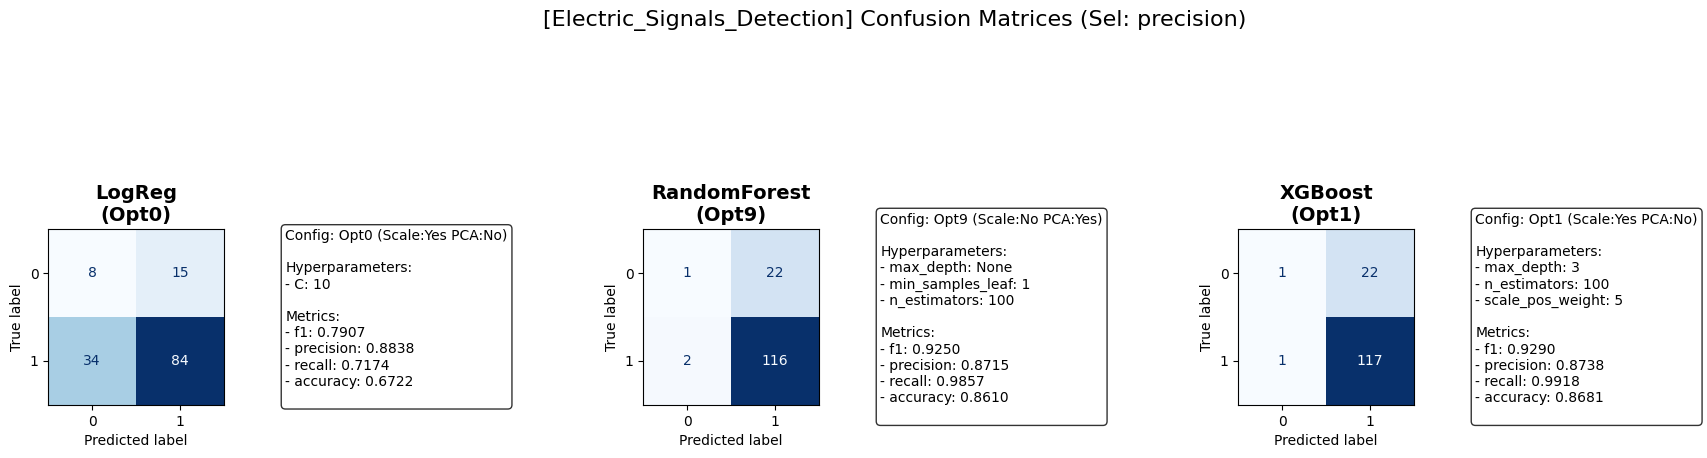


--- [Stage 2] Diagnosis: What is the specific fault? ---
   Faulty samples: 606
   Fault types found: ['align-angular' 'align-combination' 'align-parallel' 'bearing-bpfi'
 'bearing-bpfo' 'bearing-bsf' 'bearing-contaminated' 'bearing-pump'
 'bent-shaft' 'broken-rotor-bar' 'cavitation-discharge'
 'cavitation-suction' 'coupling' 'coupling-2D' 'impeller'
 'loose-foot-motor' 'loose-foot-pump' 'new-motor' 'soft-foot'
 'stator-short' 'unbalance-motor' 'unbalance-pump']

🚀 START EXPERIMENT: ELECTRIC_SIGNALS_DIAGNOSIS
📊 Target Column: 'fault_type_encoded'
📊 Metrics: ['f1_macro', 'accuracy'] (Optimizing for: f1_macro)

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: f1_macro=0.1021
   ✅ RandomForest: f1_macro=0.0937
   ✅ KNN: f1_macro=0.0853

--- ⚙️ Processing Opt1_S0_D1 ---
   ✅ XGBoost: f1_macro=0.1033
   ✅ RandomForest: f1_macro=0.0937
   ✅ KNN: f1_macro=0.0981

--- ⚙️ Processing Opt2_S1_D1 ---
   ✅ XGBoost: f1_macro=0.1026
   ✅ RandomForest: f1_macro=0.0934
   ✅ KNN: f1_macro=0.1062

--- ⚙️ 

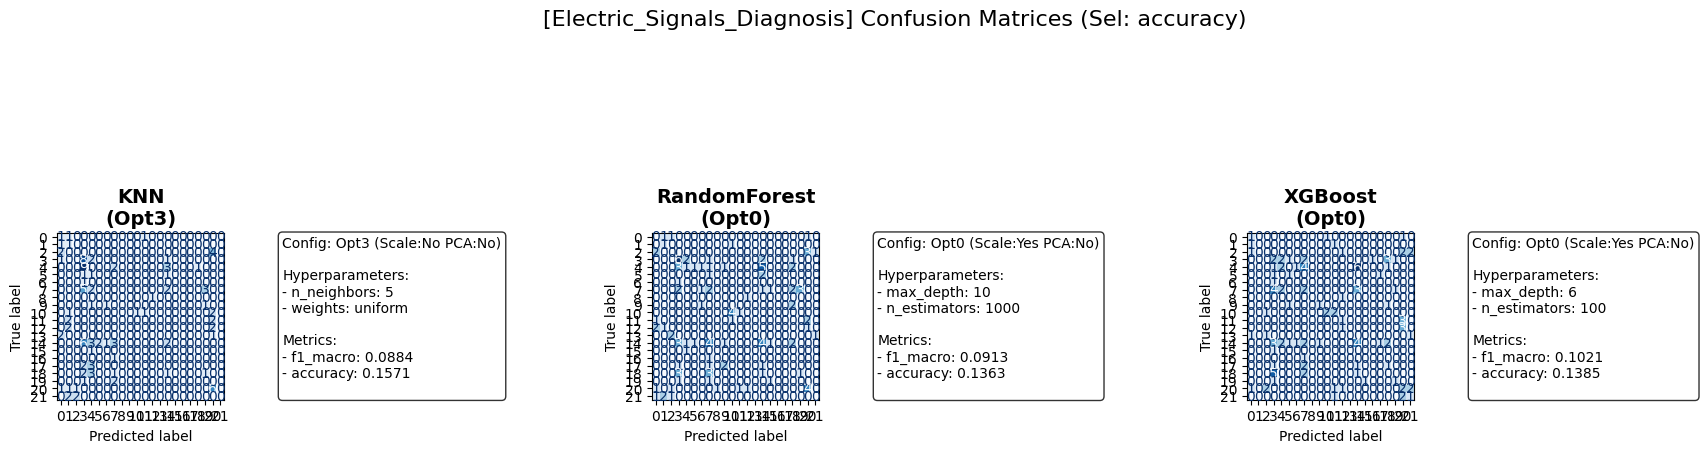


--- [Stage 3] Severity: How critical is the fault? ---

>> Analyzing Severity for: 'bearing-bpfi'
   [Option: No_Frequency]
     ✅ RandomForest: RMSE=1.2425 | R2=-0.9873
     ✅ XGBoost: RMSE=1.3547 | R2=-1.3622
     ✅ LinearReg: RMSE=1.3849 | R2=-1.4688

>> Analyzing Severity for: 'bearing-bpfo'
   [Option: No_Frequency]
     ✅ RandomForest: RMSE=1.2857 | R2=-1.1279
     ✅ XGBoost: RMSE=1.4300 | R2=-1.6321
     ✅ LinearReg: RMSE=1.3830 | R2=-1.4622

>> Analyzing Severity for: 'bearing-bsf'
   Skipping: Only 1 severity level found for bearing-bsf.

>> Analyzing Severity for: 'bearing-contaminated'
   Skipping: Only 1 severity level found for bearing-contaminated.

>> Analyzing Severity for: 'bearing-pump'
   [Option: No_Frequency]
     ✅ RandomForest: RMSE=1.1140 | R2=-0.5974
     ✅ XGBoost: RMSE=1.1929 | R2=-0.8317
     ✅ LinearReg: RMSE=1.2243 | R2=-0.9294

>> Analyzing Severity for: 'broken-rotor-bar'
   Skipping: Only 1 severity level found for broken-rotor-bar.

>> Analyzing Sever

In [18]:
import pandas as pd
import numpy as np
import re
from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from ModelEvaluator import ClassificationEvaluator

# Assuming ModelEvaluator is already defined in your notebook or imported
# from ModelEvaluator import ModelEvaluator 

def run_full_diagnostic_pipeline(df, dataset_name):
    """
    Runs the complete 3-stage Predictive Maintenance pipeline:
    1. Detection (Binary: Normal vs Faulty)
    2. Diagnosis (Multiclass: Which fault?)
    3. Severity (Regression: How bad is it?)
    """
    print(f"\n{'#'*60}")
    print(f"🏁 START PIPELINE FOR: {dataset_name.upper()}")
    print(f"{'#'*60}")

    if df is None or df.empty:
        print("⚠️ DataFrame is empty or None. Skipping.")
        return

    # Identify columns to potentially drop (e.g., thousands of Hz columns)
    freq_cols = [col for col in df.columns if '[Hz]' in col]

    # ======================================================
    # STAGE 1: FAULT DETECTION (Binary)
    # ======================================================
    print(f"\n--- [Stage 1] Detection: Is the machine faulty? ---")
    
    # Create Binary Target
    # Assumes 'failure_mode' contains 'normal' or 'healthy' for healthy data
    # We look for 'normal' (from your earlier description) or 'healthy' just in case
    df['is_faulty'] = df['failure_mode'].apply(lambda x: 0 if 'normal' in str(x).lower() or 'healthy' in str(x).lower() else 1)
    
    # Setup Evaluator
    eval_detect = ClassificationEvaluator(name=f"{dataset_name}_Detection")
    
    # --- ADD OPTIONS (2 Variations) ---
    # Option 1: Use ALL features (including thousands of Hz columns)
    eval_detect.add_option(
        scaling=True, 
        dummies=True, 
        cols_to_drop=["failure_mode", "failure_mode_cleaned"]
    )
    
    # Option 2: Drop Frequency columns (Use only Physics/Stat features)
    # Only works if you actually calculated physics features earlier!
    eval_detect.add_option(
        scaling=True, 
        dummies=True, 
        cols_to_drop=["failure_mode", "failure_mode_cleaned"] + freq_cols
    )

    eval_detect.add_option(
        scaling=False, 
        dummies=True, 
        cols_to_drop=["failure_mode", "failure_mode_cleaned"]
    )

    eval_detect.add_option(
        scaling=False, 
        dummies=True, 
        cols_to_drop=["failure_mode", "failure_mode_cleaned"] + freq_cols
    )

    eval_detect.add_option(
        scaling=True, 
        dummies=True, 
        cols_to_drop=["failure_mode", "failure_mode_cleaned"],
        n_components=0.95
    )

    eval_detect.add_option(
        scaling=False, 
        dummies=True, 
        cols_to_drop=["failure_mode", "failure_mode_cleaned"],
        pca= True,
        n_components=0.95
    )
    
    eval_detect.add_option(
        scaling=True, 
        dummies=True, 
        cols_to_drop=["failure_mode", "failure_mode_cleaned"],
        n_components=0.90,
    )

    eval_detect.add_option(
        scaling=False, 
        dummies=True, 
        cols_to_drop=["failure_mode", "failure_mode_cleaned"],
        pca= True,
        n_components=0.90
    )

    eval_detect.add_option(
        scaling=True, 
        dummies=True, 
        cols_to_drop=["failure_mode", "failure_mode_cleaned"],
        n_components=0.99
    )

    eval_detect.add_option(
        scaling=False, 
        dummies=True, 
        cols_to_drop=["failure_mode", "failure_mode_cleaned"],
        pca= True,
        n_components=0.99
    )

    # --- ADD MODELS (3 Types) ---
    
    # Model 1: XGBoost (Gradient Boosting)
    eval_detect.add_model(
        name='XGBoost',
        model=XGBClassifier(eval_metric='logloss', n_jobs=-1, random_state=42),
        params={
            'n_estimators': [100],
            'max_depth': [3, 6],
            'scale_pos_weight': [1, 5] # Handle imbalance
        }
    )

    # Model 2: RandomForest (Bagging)
    eval_detect.add_model(
        name='RandomForest',
        model=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        params={
            'n_estimators': [100, 200],
            'max_depth': [10, None],
            'min_samples_leaf': [1, 2]
        }
    )

    # Model 3: Logistic Regression (Linear Baseline)
    eval_detect.add_model(
        name='LogReg',
        model=LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42),
        params={
            'C': [0.1, 1, 10]
        }
    )
    
    # Run Stage 1
    eval_detect.run_experiments(
        df, 
        target_col='is_faulty', 
        scoring=['f1', 'precision', 'recall', 'accuracy'], 
        refit='precision'
    )
    
    # Show results
    eval_detect.plot_confusion_matrix(metric_for_selection='precision')
    
    # ======================================================
    # STAGE 2: FAULT DIAGNOSIS (Multi-class)
    # ======================================================
    print(f"\n--- [Stage 2] Diagnosis: What is the specific fault? ---")
    
    # Filter: We only diagnose machines that are actually faulty
    df_faults = df[df['is_faulty'] == 1].copy()
    
    if df_faults.empty:
        print("⚠️ No faulty data found. Skipping Stage 2 & 3.")
        return

    # 1. Clean labels (remove severity numbers)
    # "bearing-bpfi-1" -> "bearing-bpfi"
    if 'failure_mode_cleaned' in df_faults.columns:
        df_faults['fault_type_cleaned'] = df_faults['failure_mode_cleaned']
    else:
        # Fallback if cleaned col doesn't exist
        df_faults['fault_type_cleaned'] = df_faults['failure_mode'].apply(lambda x: re.sub(r'-\d+$', '', str(x)))

    # 2. ENCODE LABELS (Required for XGBoost Multi-class)
    le = LabelEncoder()
    df_faults['fault_type_encoded'] = le.fit_transform(df_faults['fault_type_cleaned'])
    
    print(f"   Faulty samples: {len(df_faults)}")
    print(f"   Fault types found: {le.classes_}")

    # Setup Evaluator
    eval_diag = ClassificationEvaluator(name=f"{dataset_name}_Diagnosis")

    # --- ADD OPTIONS (2 Variations) ---
    # Note: We drop 'is_faulty' and the text labels to prevent data leakage
    base_drops = ["failure_mode", "failure_mode_cleaned", "is_faulty", "fault_type_cleaned"]
    
    # Option 1: All features
    eval_diag.add_option(
        scaling=True, 
        dummies=True, 
        cols_to_drop=base_drops
    )

    eval_diag.add_option(
        scaling=False, 
        dummies=True, 
        cols_to_drop=base_drops
    )
    
    # Option 2: No Frequency columns
    eval_diag.add_option(
        scaling=True, 
        dummies=True, 
        cols_to_drop=base_drops + freq_cols
    )

    eval_diag.add_option(
        scaling=False, 
        dummies=True, 
        cols_to_drop=base_drops + freq_cols
    )
    
    eval_diag.add_option(
        scaling=True, 
        dummies=True, 
        cols_to_drop=base_drops,
        n_components=0.95
    )

    eval_diag.add_option(
        scaling=False, 
        dummies=True, 
        cols_to_drop=base_drops,
        pca= True,
        n_components=0.95
    )
    
    eval_diag.add_option(
        scaling=True, 
        dummies=True, 
        cols_to_drop=base_drops,
        n_components=0.90,
    )

    eval_diag.add_option(
        scaling=False, 
        dummies=True, 
        cols_to_drop=base_drops,
        pca= True,
        n_components=0.90
    )

    eval_diag.add_option(
        scaling=True, 
        dummies=True, 
        cols_to_drop=base_drops,
        n_components=0.99
    )

    eval_diag.add_option(
        scaling=False, 
        dummies=True, 
        cols_to_drop=base_drops,
        pca= True,
        n_components=0.99
    )

    # --- ADD MODELS (3 Types) ---
    
    # Model 1: XGBoost (Multi-class)
    eval_diag.add_model(
        name='XGBoost',
        model=XGBClassifier(eval_metric='mlogloss', n_jobs=-1, random_state=42),
        params={'n_estimators': [50,100,200,300,500], 'max_depth': [3, 6,10,20,50]}
    )

    # Model 2: RandomForest
    eval_diag.add_model(
        name='RandomForest',
        model=RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42),
        params={'n_estimators': [100, 200,500,1000], 'max_depth': [5,10,50, None]}
    )

    # Model 3: KNN
    eval_diag.add_model(
        name='KNN',
        model=KNeighborsClassifier(n_jobs=-1),
        params={'n_neighbors': [3, 5, 7,9,11,50], 'weights': ['uniform', 'distance']}
    )
    
    # Run Stage 2 (Use 'f1_macro' for multi-class balance)
    eval_diag.run_experiments(
        df_faults, 
        target_col='fault_type_encoded', 
        scoring=['f1_macro', 'accuracy'], 
        refit='f1_macro'
    )
    
    eval_diag.plot_confusion_matrix(metric_for_selection='accuracy')

    # ======================================================
    # STAGE 3: SEVERITY ESTIMATION (Regression)
    # ======================================================
    print(f"\n--- [Stage 3] Severity: How critical is the fault? ---")
    
    # We loop through each unique fault type found in Stage 2
    unique_faults = df_faults['fault_type_cleaned'].unique()
    
    for fault in unique_faults:
        print(f"\n>> Analyzing Severity for: '{fault}'")
        
        # Filter data for this specific fault
        df_severity = df_faults[df_faults['fault_type_cleaned'] == fault].copy()
        
        # Extract Severity Level (The number at the end of original failure_mode)
        def get_severity(val):
            match = re.search(r'-(\d+)$', str(val))
            return int(match.group(1)) if match else 0
            
        df_severity['severity_score'] = df_severity['failure_mode'].apply(get_severity)
        
        # Check if we have enough variation to do regression (need at least 2 levels)
        if df_severity['severity_score'].nunique() < 2:
            print(f"   Skipping: Only 1 severity level found for {fault}.")
            continue

        # Prepare Data for Regression
        # Drop labels and text columns. 
        # We iterate over 2 options manually here (All Features vs No Freq)
        
        options = {
            # "All_Features": [],
            "No_Frequency": freq_cols
        }
        
        base_drops_reg = ['failure_mode', 'failure_mode_cleaned', 'fault_type_cleaned', 
                          'is_faulty', 'severity_score', 'motor_type', 'percentage_rated_speed', 
                          'fault_type_encoded']

        for opt_name, extra_drops in options.items():
            print(f"   [Option: {opt_name}]")
            
            # Select Numeric Features
            cols_to_drop = base_drops_reg + extra_drops
            X = df_severity.drop(columns=cols_to_drop, errors='ignore').select_dtypes(include=[np.number])
            y = df_severity['severity_score']
            
            # Split
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
            
            # --- COMPARE 3 REGRESSION MODELS ---
            regressors = {
                'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
                'XGBoost': XGBRegressor(n_estimators=100, n_jobs=-1, random_state=42),
                'LinearReg': LinearRegression()
            }

            for model_name, reg in regressors.items():
                reg.fit(X_train, y_train)
                y_pred = reg.predict(X_test)
                
                rmse = np.sqrt(mean_squared_error(y_test, y_pred))
                r2 = r2_score(y_test, y_pred)
                
                print(f"     ✅ {model_name}: RMSE={rmse:.4f} | R2={r2:.4f}")

# ======================================================
# EXECUTE PIPELINE
# ======================================================

# Example usage:
run_full_diagnostic_pipeline(df_elec_feat, dataset_name="Electric_Signals")


############################################################
🏁 START PIPELINE FOR: VIBRATION_SIGNALS
############################################################

--- [Stage 1] Detection: Is the machine faulty? ---

🚀 START EXPERIMENT: VIBRATION_SIGNALS_DETECTION
📊 Target Column: 'is_faulty'
📊 Metrics: ['f1', 'precision', 'recall', 'accuracy'] (Optimizing for: precision)

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.8679
   ✅ RandomForest: precision=0.8641
   ✅ LogReg: precision=0.8904

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.8762
   ✅ RandomForest: precision=0.8779
   ✅ LogReg: precision=0.8880

--- ⚙️ Processing Opt2_S0_D1 ---
   ✅ XGBoost: precision=0.8679
   ✅ RandomForest: precision=0.8641
   ✅ LogReg: precision=0.9063

--- ⚙️ Processing Opt3_S0_D1 ---
   ✅ XGBoost: precision=0.8762
   ✅ RandomForest: precision=0.8779
   ✅ LogReg: precision=0.8865

--- ⚙️ Processing Opt4_S1_D1 ---
   ✅ XGBoost: precision=0.8679
   ✅ RandomForest: precision=0.8641


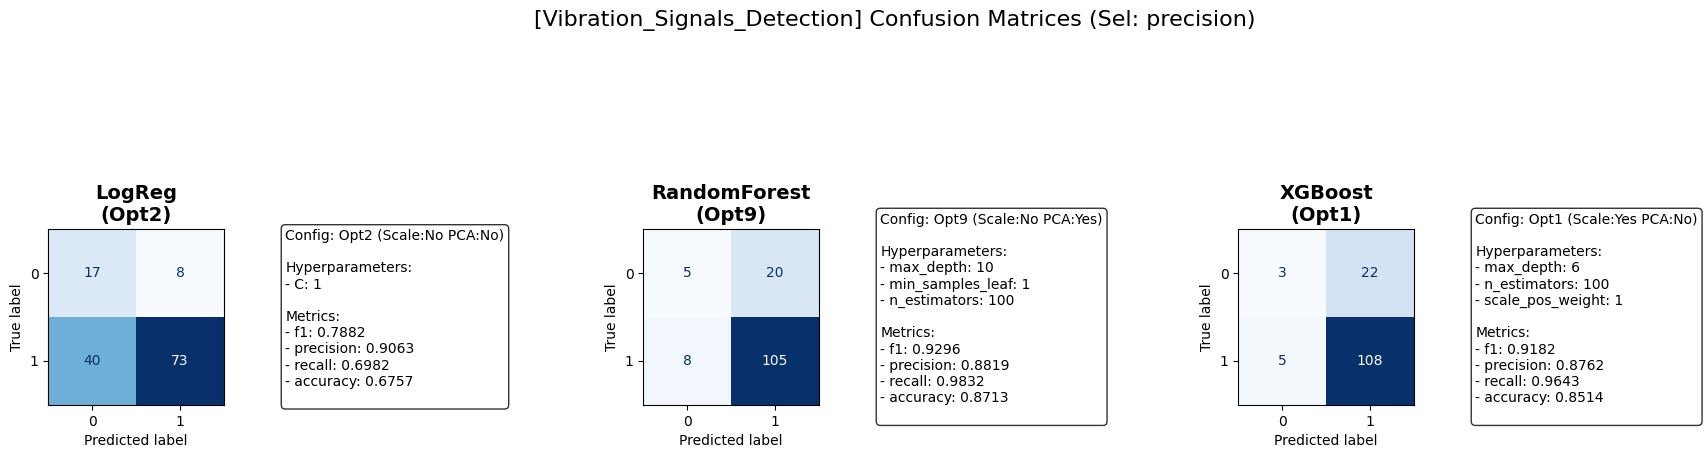


--- [Stage 2] Diagnosis: What is the specific fault? ---
   Faulty samples: 590
   Fault types found: ['align-angular' 'align-combination' 'align-parallel' 'bearing-bpfi'
 'bearing-bpfo' 'bearing-bsf' 'bearing-contaminated' 'bearing-pump'
 'bent-shaft' 'broken-rotor-bar' 'cavitation-discharge'
 'cavitation-suction' 'coupling' 'coupling-2D' 'impeller'
 'loose-foot-motor' 'loose-foot-pump' 'new-motor' 'soft-foot'
 'stator-short' 'unbalance-motor' 'unbalance-pump']

🚀 START EXPERIMENT: VIBRATION_SIGNALS_DIAGNOSIS
📊 Target Column: 'fault_type_encoded'
📊 Metrics: ['f1_macro', 'accuracy'] (Optimizing for: f1_macro)

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: f1_macro=0.2789
   ✅ RandomForest: f1_macro=0.2639
   ✅ KNN: f1_macro=0.3182

--- ⚙️ Processing Opt1_S0_D1 ---
   ✅ XGBoost: f1_macro=0.2789
   ✅ RandomForest: f1_macro=0.2639
   ✅ KNN: f1_macro=0.3098

--- ⚙️ Processing Opt2_S1_D1 ---
   ✅ XGBoost: f1_macro=0.2530
   ✅ RandomForest: f1_macro=0.2716
   ✅ KNN: f1_macro=0.2634

--- ⚙️

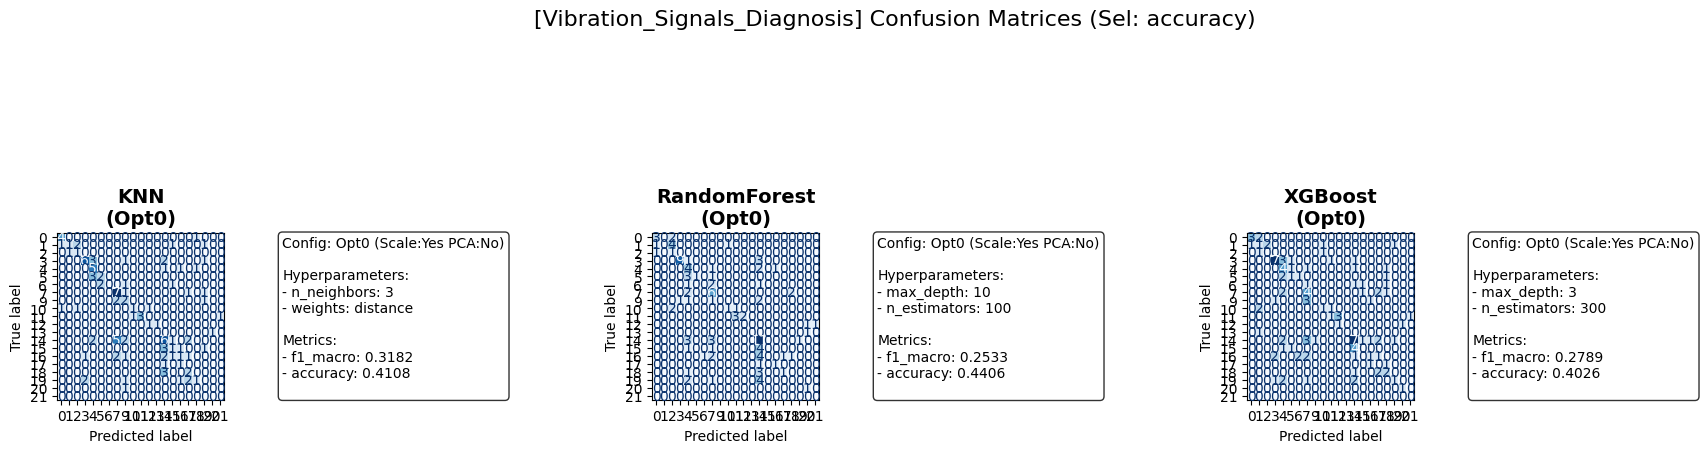


--- [Stage 3] Severity: How critical is the fault? ---

>> Analyzing Severity for: 'bearing-bpfi'
   [Option: No_Frequency]
     ✅ RandomForest: RMSE=0.9360 | R2=-0.3948
     ✅ XGBoost: RMSE=0.9077 | R2=-0.3118
     ✅ LinearReg: RMSE=1.1031 | R2=-0.9373

>> Analyzing Severity for: 'bearing-bpfo'
   [Option: No_Frequency]
     ✅ RandomForest: RMSE=0.9175 | R2=-0.3176
     ✅ XGBoost: RMSE=1.0848 | R2=-0.8421
     ✅ LinearReg: RMSE=0.8961 | R2=-0.2568

>> Analyzing Severity for: 'bearing-bsf'
   Skipping: Only 1 severity level found for bearing-bsf.

>> Analyzing Severity for: 'bearing-contaminated'
   Skipping: Only 1 severity level found for bearing-contaminated.

>> Analyzing Severity for: 'bearing-pump'
   [Option: No_Frequency]
     ✅ RandomForest: RMSE=0.7960 | R2=0.0083
     ✅ XGBoost: RMSE=0.7380 | R2=0.1474
     ✅ LinearReg: RMSE=0.9465 | R2=-0.4023

>> Analyzing Severity for: 'broken-rotor-bar'
   Skipping: Only 1 severity level found for broken-rotor-bar.

>> Analyzing Severit

In [19]:
# 2. Run for Vibration Data
# (Assuming df_vibration_final is your processed dataframe)
run_full_diagnostic_pipeline(df_vib_feat, dataset_name="Vibration_Signals")